# Hydra Configuration Management

The following tutorial demonstrates how one may calibrate a simulation model using [Hydra configuration files](https://hydra.cc/), which `calisim` incorporates as an optional dependency.

Hydra may be used to specify complex calibration procedures within composable YAML files. We will henceforth provide a basic example. 

In [20]:
import numpy as np
import pandas as pd

from calisim.config import HydraConfiguration

import warnings
warnings.filterwarnings("ignore")

## YAML Configuration

We will first instantiate a Hydra configuration object. This contains various utility functions for working with Hydra configuration files. 

In [21]:
hydra_config = HydraConfiguration()

We will next view the contents of the `conf` directory, which contains the `config.yaml` file, alongside three subdirectories:

- calibration
- metric
- model

In [22]:
! ls conf

calibration  config.yaml  metric  model


The contents of `config.yaml` are as follows:

```yaml
defaults:
  - _self_
  - calibration: lotka_optimisation
  - model: lotka_volterra
  - metric: mse
```

We can see that the three elements within the `defaults` list (`calibration`, `model`, `metric`) match the three subdirectory names above. Let's look at the files within the `metric` subdirectory.

In [23]:
! ls conf/metric

mse.yaml


We see a YAML file called `mse.yaml`, which matches the value of the `metric` element in the `defaults` list.

```yaml
defaults:
  ...
  - metric: mse
```

The contents of the `mse.yaml` are as follows:

```yaml
_target_: calisim.statistics.MeanSquaredError
```

Similarly, the `model` subdirectory contains a YAML file called `lotka_volterra.yaml` which is composed of the following:

```yaml
_target_: calisim.example_models.LotkaVolterraModel
```

This should give you an idea of how Hydra works. Hydra will instantiate a configuration dictionary containing three keys (`calibration`, `model`, `metric`) The `metric` key will be mapped to a `MeanSquaredError` object while the `model` key will be mapped to a `LotkaVolterraModel` object.

But how about the the `calibration` key? Referring to the `defaults` list again:

```yaml
defaults:
  - _self_
  - calibration: lotka_optimisation
```

Within the `calibration` subdirectory, there exists a YAML file called `lotka_optimisation.yaml`. This file a bit more complicated:

```yaml
_target_: calisim.optimisation.OptimisationMethod
_partial_: true
engine: emukit
specification:
    _target_: calisim.optimisation.OptimisationMethodModel
    experiment_name: emukit_optimisation
    parameter_spec: 
        parameters:
            - name: alpha
              distribution_name: uniform
              distribution_args: [0.45, 0.55]
              data_type: continuous
            - name: beta
              distribution_name: uniform
              distribution_args: [0.02, 0.03]
              data_type: continuous
    directions: [ minimize ]
    output_labels: [ Lynx ]
    acquisition_func: ei
    n_iterations: 25
    n_init: 20
    n_samples: 100
    n_out: 1
    verbose: false
    method_kwargs:
        noise_var: 0.001
```

So, the `calibration` key is mapped to an `OptimisationMethod` object that uses the `emukit` engine. Under `specification`, we can see the `parameter_spec` containing parameter distribution information, the acquisition function (`ei`), the number of iterations (25), and so on. However, the `OptimisationMethod` object has a mandatory argument within its constructor called `calibration_func`, which we have not defined in the YAML file (note that it is possible to specify a particular calibration function by providing its full module path and name). In order to instantiate `OptimisationMethod`, we include `_partial_: true` so that we can dynamically specify `calibration_func` within our Python code.

## Instantiation

Let's construct a raw configuration object from the `config.yaml` file.

In [24]:
cfg = hydra_config.get_raw_config("config", "conf")
print(hydra_config.pretty(cfg))

calibration:
  _target_: calisim.optimisation.OptimisationMethod
  _partial_: true
  engine: emukit
  specification:
    _target_: calisim.optimisation.OptimisationMethodModel
    experiment_name: emukit_optimisation
    parameter_spec:
      parameters:
      - name: alpha
        distribution_name: uniform
        distribution_args:
        - 0.45
        - 0.55
        data_type: continuous
      - name: beta
        distribution_name: uniform
        distribution_args:
        - 0.02
        - 0.03
        data_type: continuous
    directions:
    - minimize
    output_labels:
    - Lynx
    acquisition_func: ei
    n_iterations: 25
    n_init: 20
    n_samples: 100
    n_out: 1
    verbose: false
    method_kwargs:
      noise_var: 0.001
model:
  _target_: calisim.example_models.LotkaVolterraModel
metric:
  _target_: calisim.statistics.MeanSquaredError



This contains the contents of the aforementioned YAML files within a single dictionary. However, we can instead construct a configuration object and instantiate all of the classes mapped to the `_target_` keys.

In [25]:
cfg = hydra_config.get_configuration("config", "conf")

In [26]:
metric = cfg["metric"]
type(metric)

calisim.statistics.discrepancy.MeanSquaredError

In [27]:
model = cfg["model"]
observed_data = model.get_observed_data()
type(model)

calisim.example_models.lotka_volterra.LotkaVolterraModel

You can see that we have instantiated `MeanSquaredError` and `LotkaVolterraModel` objects. Note that we can also override the contents of the YAML configuration files.

For instance, we can instead instantiate a `RootMeanSquaredError` metric object like so:

In [28]:
cfg = hydra_config.get_configuration(
    "config", "conf", 
    overrides=["metric._target_=calisim.statistics.RootMeanSquaredError"]
)
metric = cfg["metric"]
type(metric)

calisim.statistics.discrepancy.RootMeanSquaredError

`Hydra` enables us to compose highly complex calibration workflows by mixing, matching, and overriding various sets of YAML files and keys. It is certainly possible to implement much more complicated configuration specifications, though we will keep things simple for this tutorial.

## Calibration

Let's next define our objective function for calibration.

In [29]:
def objective(
	parameters: dict, simulation_id: str, observed_data: np.ndarray | None, t: pd.Series
) -> float | list[float]:
	simulation_parameters = dict(h0=34.0, l0=5.9, t=t, gamma=0.84, delta=0.026)

	for k in ["alpha", "beta"]:
		simulation_parameters[k] = parameters[k]

	simulated_data = model.simulate(simulation_parameters).lynx.values
	discrepancy = metric.calculate(observed_data, simulated_data)
	return discrepancy

Finally, we can instantiate a calibrator object, then `specify`, `execute`, and `analyze`a calibration workflow. As mentioned prior, we must dynamically specify the `calibration_func` in the calibrator's constructor using our objective function.

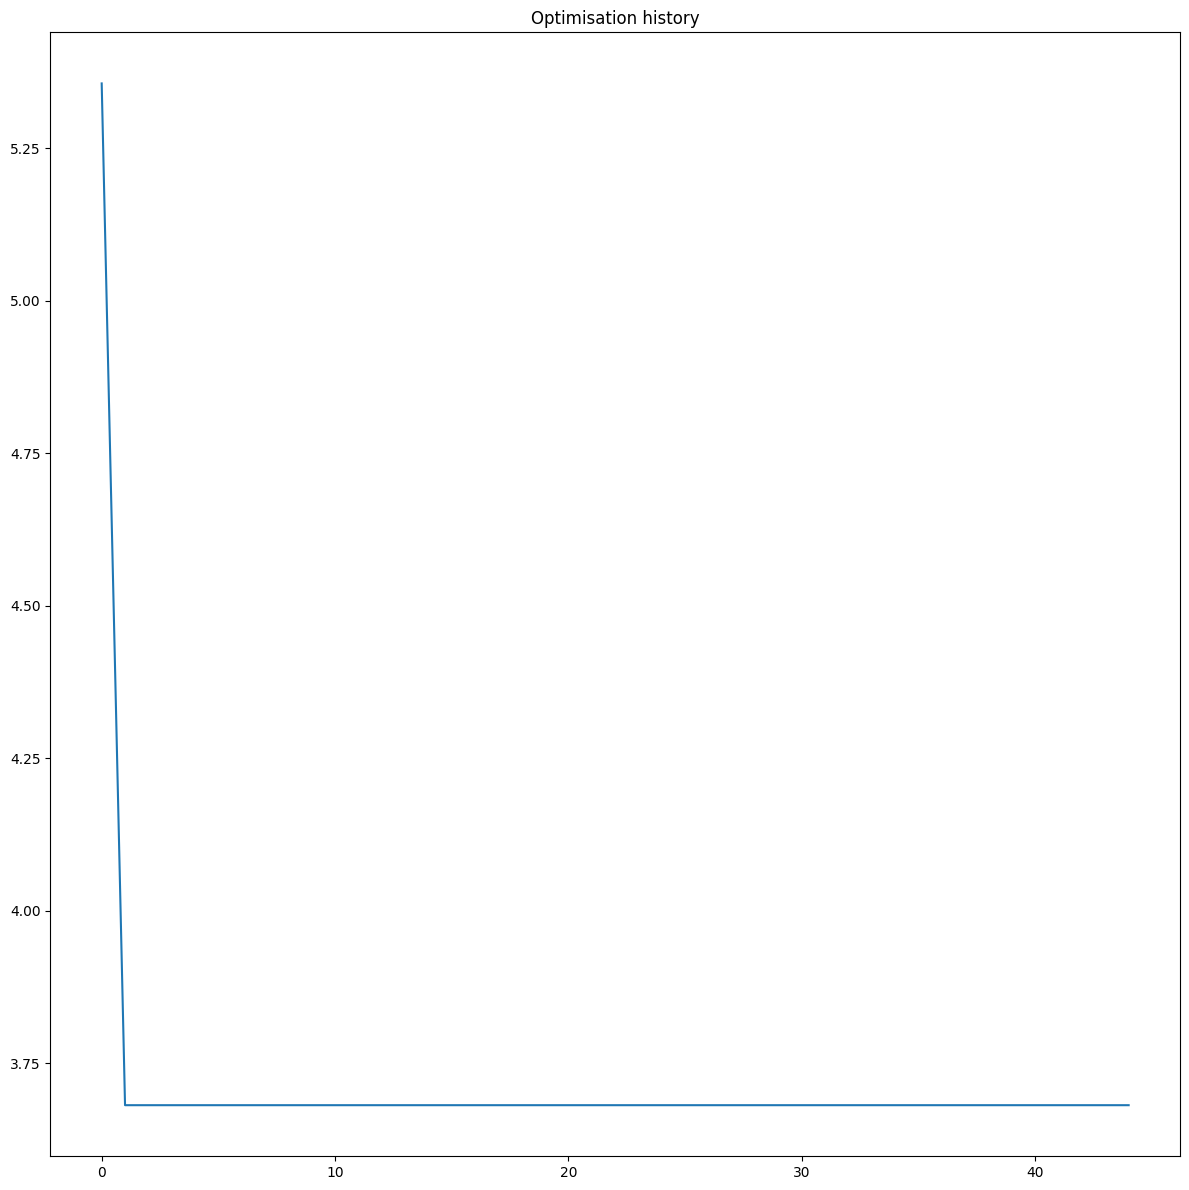

In [30]:
calibrator = cfg["calibration"](calibration_func=objective)
calibrator.specification.calibration_func_kwargs=dict(t=observed_data.year)
calibrator.specification.observed_data=observed_data.lynx.values
calibrator.specify().execute().analyze()

The optimiser is able to retrieve the ground-truth parameter values from our simulation study.

In [31]:
pd.DataFrame([
    { "parameter": estimate.name, "estimate": estimate.estimate, "ground truth": model.GROUND_TRUTH[estimate.name] }
    for estimate in calibrator.get_parameter_estimates().estimates
])

,parameter,estimate,ground truth
0,alpha,0.518041,0.520
1,beta,0.024410,0.024


Let's repeat the calibration procedure. But this time, we shall use a `Kriging` surrogate model for Bayesian optimisation via the `openturns` engine. Pulling all the above code together:

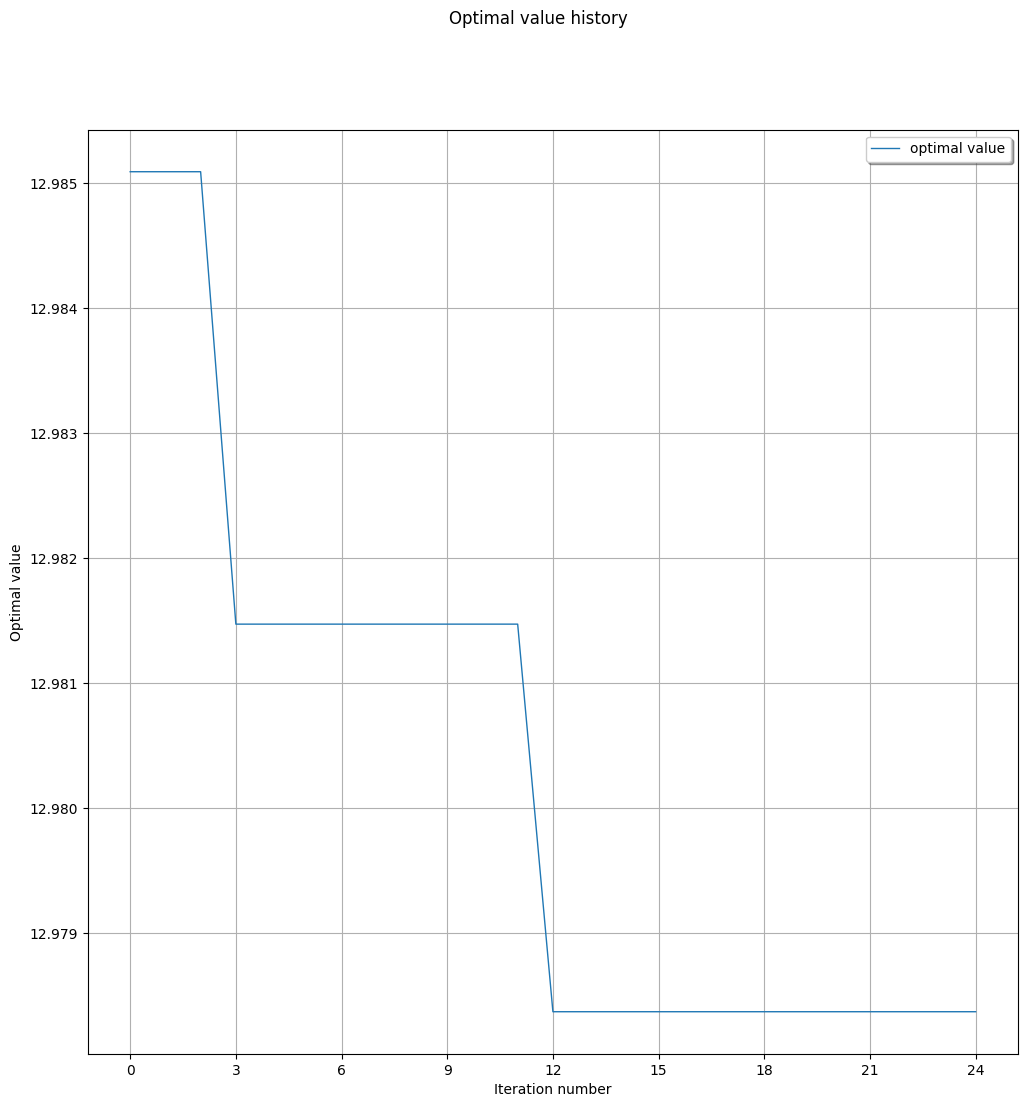

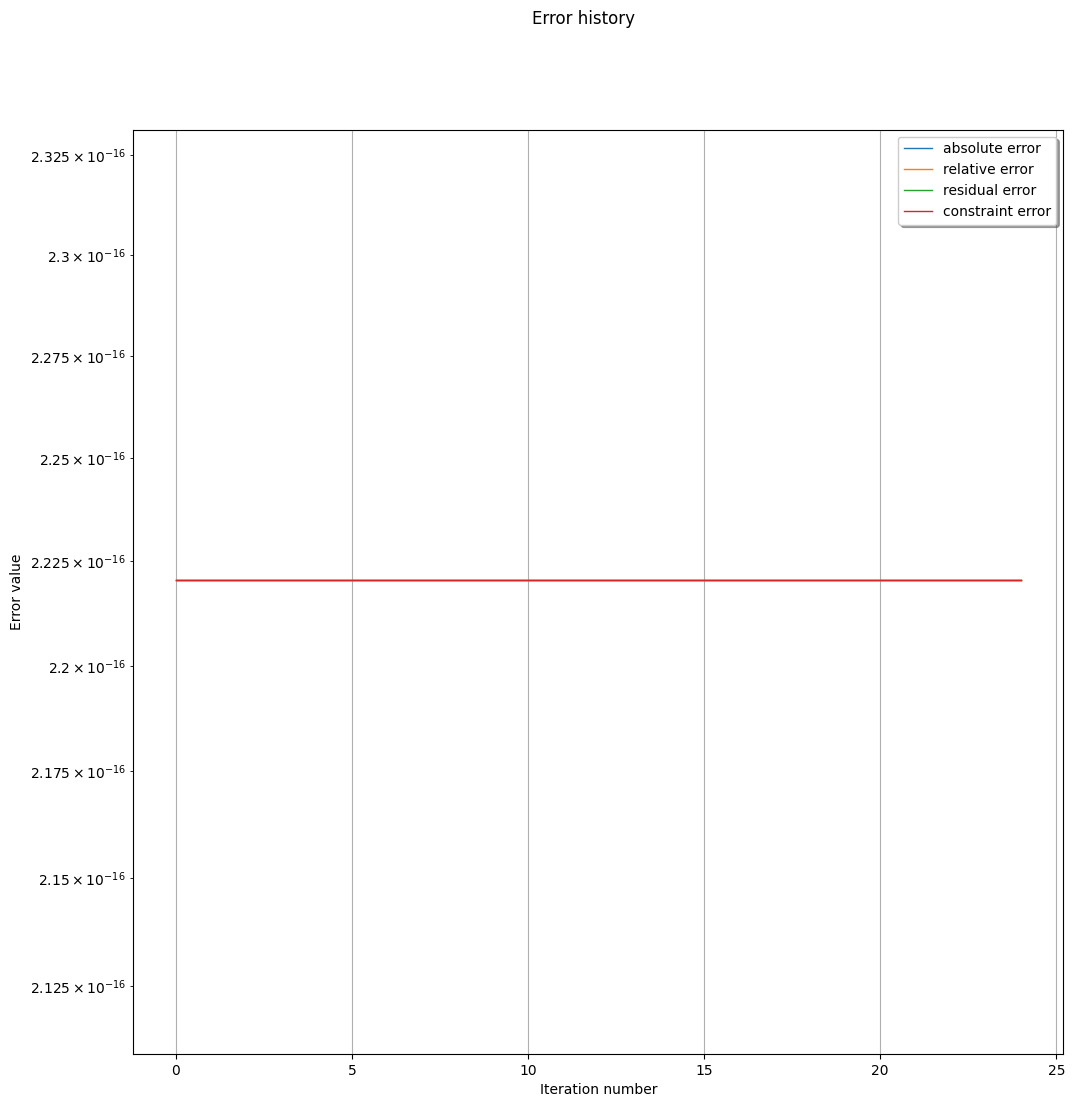

In [32]:
cfg = hydra_config.get_configuration(
    "config", 
    "conf", 
    overrides=[
        "calibration.engine=openturns",
        "+calibration.specification.method=kriging",
        "calibration.specification.method_kwargs=null"
    ]
)
metric = cfg["metric"]
model = cfg["model"]
observed_data = model.get_observed_data()

def objective(
	parameters: dict, simulation_id: str, observed_data: np.ndarray | None, t: pd.Series
) -> float | list[float]:
	simulation_parameters = dict(h0=34.0, l0=5.9, t=t, gamma=0.84, delta=0.026)

	for k in ["alpha", "beta"]:
		simulation_parameters[k] = parameters[k]

	simulated_data = model.simulate(simulation_parameters).lynx.values
	discrepancy = metric.calculate(observed_data, simulated_data)
	return discrepancy

calibrator = cfg["calibration"](calibration_func=objective)
calibrator.specification.calibration_func_kwargs=dict(t=observed_data.year)
calibrator.specification.observed_data=observed_data.lynx.values
calibrator.specify().execute().analyze() 

In [33]:
pd.DataFrame([
    { "parameter": estimate.name, "estimate": estimate.estimate, "ground truth": model.GROUND_TRUTH[estimate.name] }
    for estimate in calibrator.get_parameter_estimates().estimates
])

,parameter,estimate,ground truth
0,alpha,0.511805,0.520
1,beta,0.024113,0.024


We can see that OpenTurns is also able to recover the ground truth parameters.